In [45]:
# from google.colab import drive
# drive.mount('/content/drive')

In [46]:
# !ls /content/drive/MyDrive/dataset_don_delete

In [47]:
! pip install kneed

# Feature Engineering

## Step 1: Prepare data for downstream **analysis**

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from datetime import datetime
import holidays
from sklearn.cluster import KMeans
from kneed import KneeLocator
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
import os
from IPython.display import Markdown, display
os.environ["JOBLIB_MULTIPROCESSING"] = "0"
warnings.filterwarnings('ignore')

## Load Data

In [49]:
# from google.colab import files
# uploaded = files.upload()
df = pd.read_excel("Road Accident Data.xlsx", dtype=str, na_filter=False)
# df = pd.read_excel('/content/drive/MyDrive/dataset_don_delete/Road Accident Data.xlsx',  dtype=str, na_filter=False)
# df = pd.read_excel('/content/drive/MyDrive/temp/Road Accident Data 100k.xlsx', dtype=str, na_filter=False)
df['Carriageway_Hazards'] = df['Carriageway_Hazards'].replace({'None': 'IsNone'})
print("Original shape:", df.shape)
print(df.columns)

Original shape: (307973, 21)
Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


Remove duplicates

In [50]:
# Remove duplicates
cols_exclude_accident_index = [col for col in df.columns if col != 'Accident_Index']
# If all columns are duplicated, keep only the first occurrence
rows_before = len(df)
df.drop_duplicates(keep='first', inplace=True)
rows_after = len(df)
print(f"Removed {rows_before - rows_after} duplicate rows (all columns duplicated).")
# If all columns except 'Accident_Index' are identical, treat the row as duplicate and keep only one.
rows_before = len(df)
df = df[~df.duplicated(subset=cols_exclude_accident_index, keep='first')]
rows_after = len(df)
print(f"Removed {rows_before - rows_after} duplicate rows (all columns except 'Accident_Index' are identical).")

Removed 1 duplicate rows (all columns duplicated).
Removed 1 duplicate rows (all columns except 'Accident_Index' are identical).


Drop 'Accident_Index'

In [51]:
# Drop 'Accident_Index' column first
if 'Accident_Index' in df.columns:
    df = df.drop(columns=['Accident_Index'])
    print(f"\nDropped 'Accident_Index' column")


Dropped 'Accident_Index' column


Fill missing values

In [52]:
# Replace missing tokens with NaN (before type conversion)
print("\nReplacing missing tokens with NaN...")
missing_tokens = ['', 'NA', 'N/A', 'na', 'n/a', 'NaN', 'nan', 'None', 'NULL', '-', '--']
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.replace(missing_tokens, np.nan)

# Convert data types
print("\nConverting data types...")
numeric_cols = ['Latitude', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'Accident Date' in df.columns:
    df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')
if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

# Fill missing values
print("\nFilling missing values...")
total_filled_numeric = 0
for col in numeric_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            total_filled_numeric += missing_count
            print(f"  Filled {missing_count} rows in {col} with median: {median_val}")
if total_filled_numeric > 0:
    print(f"Total rows filled for numeric columns: {total_filled_numeric}")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
total_filled_categorical = 0
for col in categorical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        mode_vals = df[col].mode()
        mode_val = mode_vals[0] if not mode_vals.empty else 'Unknown'
        df[col] = df[col].fillna(mode_val)
        total_filled_categorical += missing_count
        print(f"  Filled {missing_count} rows in {col} with mode: {mode_val}")
if total_filled_categorical > 0:
    print(f"Total rows filled for categorical columns: {total_filled_categorical}")


Replacing missing tokens with NaN...

Converting data types...

Filling missing values...
  Filled 3 rows in Carriageway_Hazards with mode: IsNone
  Filled 317 rows in Road_Surface_Conditions with mode: Dry
  Filled 1534 rows in Road_Type with mode: Single carriageway
  Filled 17 rows in Time with mode: 17:00:00
  Filled 6057 rows in Weather_Conditions with mode: Fine no high winds
Total rows filled for categorical columns: 7928


Correct outlier word, modity 'Fetal' to 'Fatal'

In [53]:
# Modify the typo of 'Fetal' to 'Fatal'
if 'Accident_Severity' in df.columns:
    rows_with_fetal = (df['Accident_Severity'] == 'Fetal').sum()
    if rows_with_fetal > 0:
        df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')
        print(f"Fixed {rows_with_fetal} rows: 'Fetal' -> 'Fatal'")

Fixed 49 rows: 'Fetal' -> 'Fatal'


Temporal features from date and add 'Number_of_Casualties' and 'Speed_Category'

In [54]:
# Temporal features from date
if 'Accident Date' in df.columns:
    df['Year'] = df['Accident Date'].dt.year
    df['Month'] = df['Accident Date'].dt.month
    df['Day'] = df['Accident Date'].dt.day
    df['DayOfYear'] = df['Accident Date'].dt.dayofyear
    df['WeekOfYear'] = df['Accident Date'].dt.isocalendar().week
    df['IsWeekend'] = df['Accident Date'].dt.dayofweek.isin([5, 6]).astype(int)
    years = df['Accident Date'].dt.year.unique()
    uk_holidays = set()
    for year in years:
        uk_holidays.update(holidays.UnitedKingdom(years=year, subdiv='England'))
    df['IsHoliday'] = (
        df['Accident Date'].dt.date.isin([d for d in uk_holidays])
    ).astype('string').replace({True: 'Holiday', False: 'NotHoliday'})

print(f"Time's: {df['Time'].head()}")
# Time-based features
if 'Time' in df.columns:
    df['Hour'] = pd.to_datetime(df['Time'].astype(str), format='%H:%M:%S', errors='coerce').dt.hour
    df['Time_Period'] = df['Hour'].apply(lambda h: 'Morning' if 6 <= h < 12 else
                                         'Afternoon' if 12 <= h < 18 else
                                         'Evening' if 18 <= h < 22 else 'Night' if pd.notna(h) else 'Unknown')

Time's: 0    15:11:00
1    10:59:00
2    14:19:00
3    08:10:00
4    17:25:00
Name: Time, dtype: object


In [55]:
original_features = df.shape[1]
# Interaction features
if 'Number_of_Casualties' in df.columns and 'Number_of_Vehicles' in df.columns:
    df['Casualties_Per_Vehicle'] = df['Number_of_Casualties'] / (df['Number_of_Vehicles'] + 1)
    df['High_Casualty_Flag'] = (df['Number_of_Casualties'] > df['Number_of_Casualties'].median()).astype(int)

# Speed categories
if 'Speed_limit' in df.columns:
    df['Speed_Category'] = df['Speed_limit'].apply(lambda s: 'Low' if s <= 30 else 'Medium' if s <= 50 else 'High')

Use K-Means to concert latitude and longitude to 'Geo_Cluster'


Evaluating the optimal number of clusters (elbow rule)...

The optimal number of clusters detected: 5


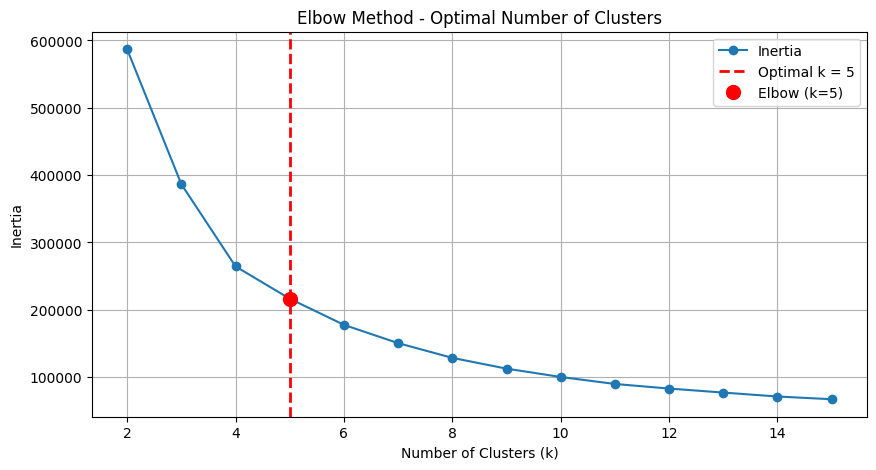

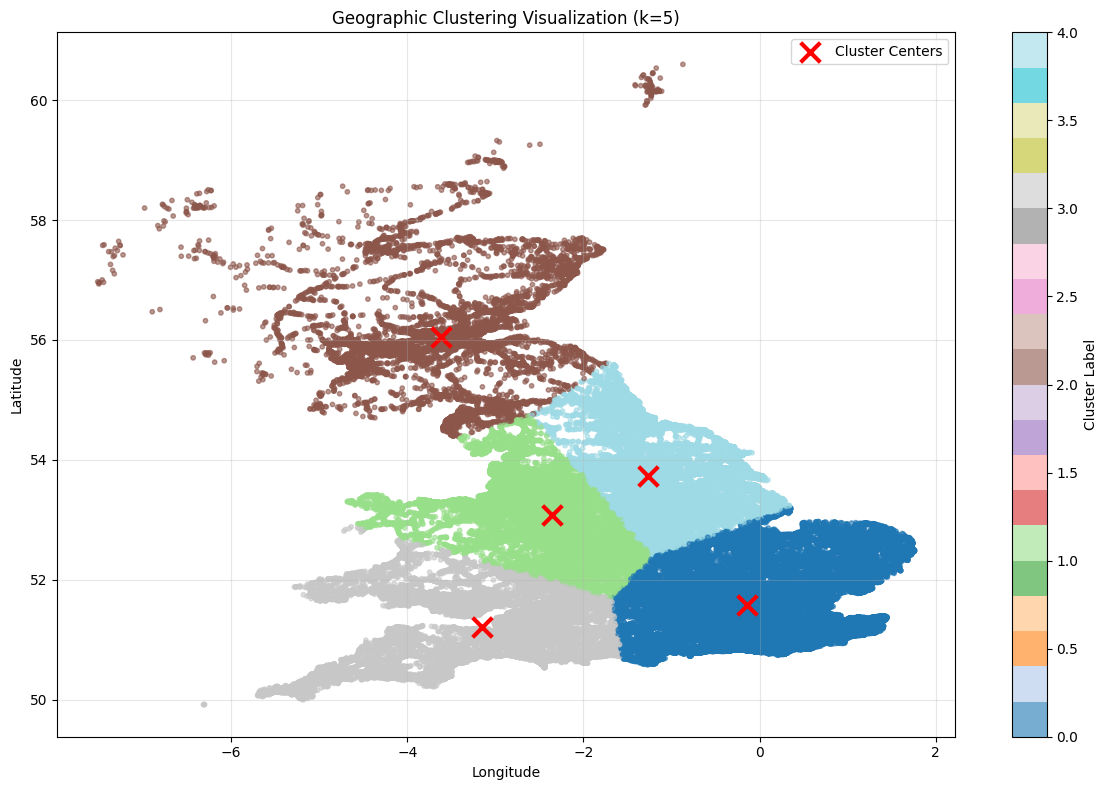

In [56]:
# Concert latitude and longitude to a new feature
coords = df[["Latitude", "Longitude"]].dropna()
print("\nEvaluating the optimal number of clusters (elbow rule)...")
inertias = []
k_range = range(2, 16)
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10);
    kmeans_test.fit(coords)
    inertias.append(kmeans_test.inertia_)
# Use KneeLocator to find the optimal elbow point
kl = KneeLocator(list(k_range), inertias, curve='convex', direction='decreasing')
n_clusters = kl.elbow
print(f"\nThe optimal number of clusters detected: {n_clusters}")
# Plot the elbow rule graph, and mark the found elbow point
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', label='Inertia')
if n_clusters is not None:
    plt.axvline(x=n_clusters, color='r', linestyle='--', linewidth=2,
                label=f'Optimal k = {n_clusters}')
    plt.plot(n_clusters, inertias[n_clusters - k_range[0]], 'ro', markersize=10,
             label=f'Elbow (k={n_clusters})')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.legend()
plt.grid(True)
plt.show()
plt.close()
# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(coords);
cluster_labels = kmeans.labels_

df["Geo_Cluster"] = np.nan
df.loc[coords.index, "Geo_Cluster"] = cluster_labels

plt.figure(figsize=(12, 8))
scatter = plt.scatter(coords["Longitude"], coords["Latitude"],
                     c=cluster_labels, cmap='tab20', s=10, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0],
           marker='x', s=200, c='red', linewidths=3, label='Cluster Centers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Geographic Clustering Visualization (k={n_clusters})')
plt.colorbar(scatter, label='Cluster Label')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

Log1p transfromation for 'Casualties_Per_Vehicle' and 'Number_of_Vehicles'

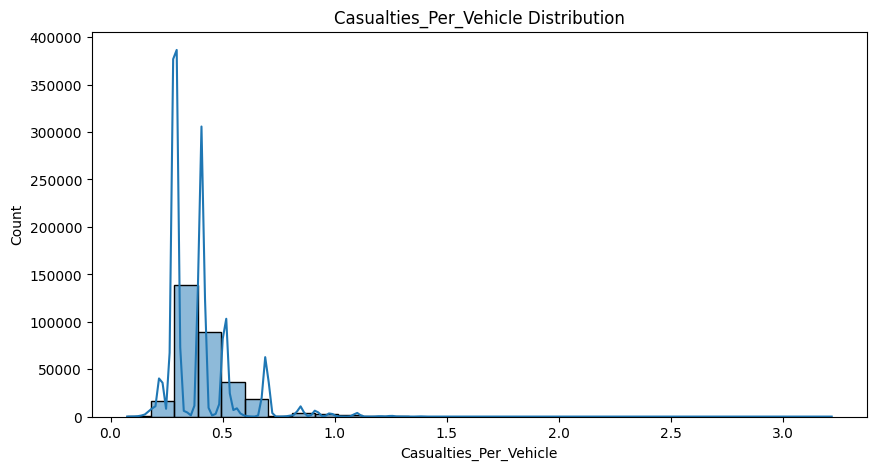

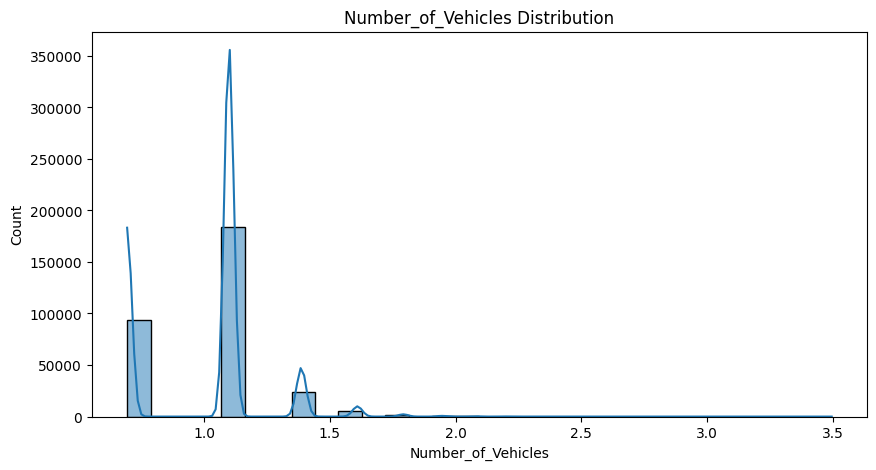

In [57]:
# log1p transformation
for col in ['Casualties_Per_Vehicle', 'Number_of_Vehicles']:
    if df[col].skew() > 0:
        df[col] = np.log1p(df[col])
# draw the distribution of the features
for col in ['Casualties_Per_Vehicle', 'Number_of_Vehicles']:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'{col} Distribution')
    plt.show()
    plt.close()

Drop some original features beacause we have used new features to replace them.

In [58]:
df.drop(['Accident Date', 'Time','Number_of_Casualties','Speed_limit','Longitude','Latitude'],axis=1, inplace=True)
print(df.columns)

Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Light_Conditions', 'Local_Authority_(District)',
       'Carriageway_Hazards', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type', 'Year', 'Month', 'Day',
       'DayOfYear', 'WeekOfYear', 'IsWeekend', 'IsHoliday', 'Hour',
       'Time_Period', 'Casualties_Per_Vehicle', 'High_Casualty_Flag',
       'Speed_Category', 'Geo_Cluster'],
      dtype='object')


## Heatmap and drop strongly correlated features

CORRELATION MATRIX


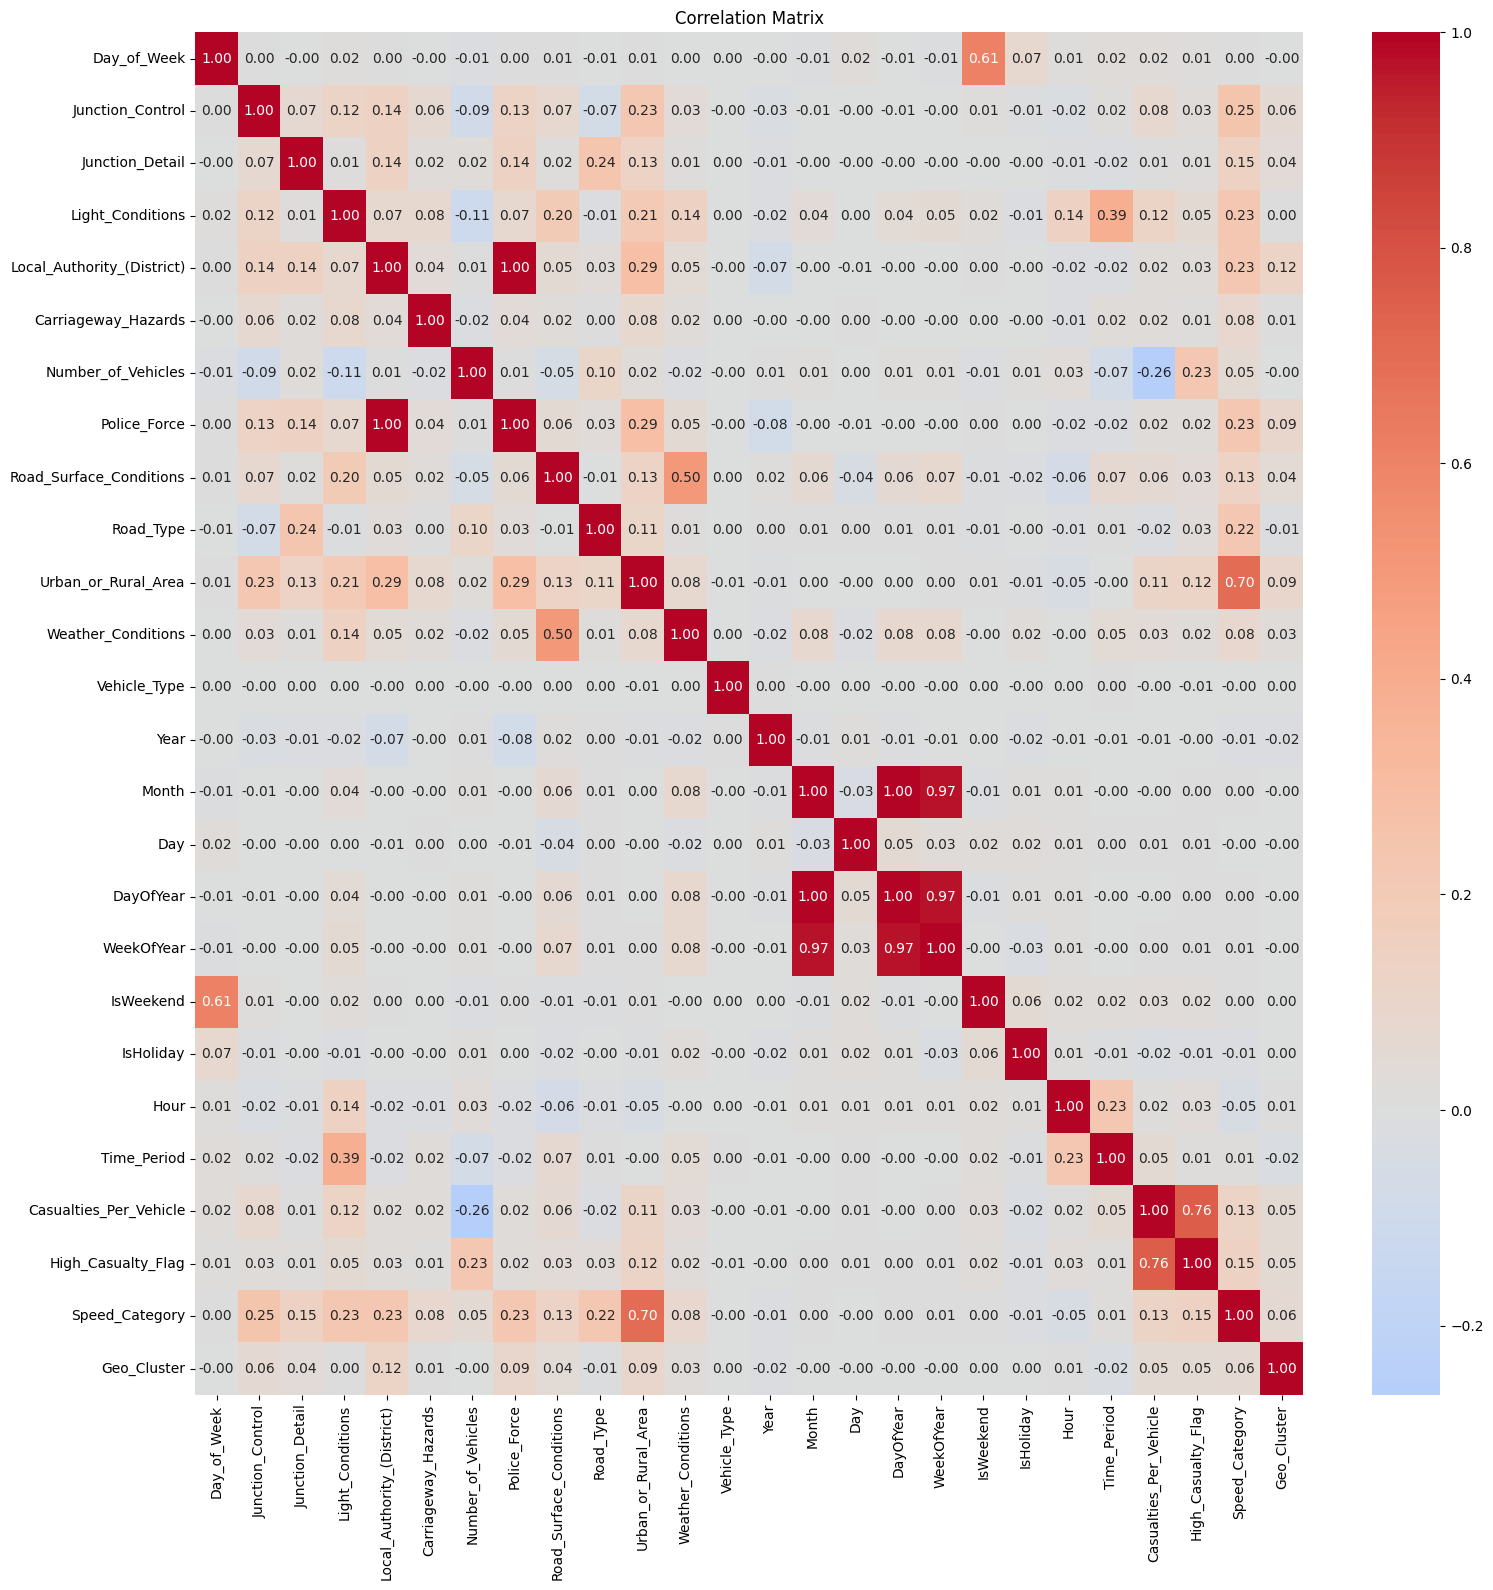

In [59]:
# Observe Multicollinearity and delete redundant features.
df_copy = df.drop('Accident_Severity', axis=1).copy()
numerical_cols = df_copy.select_dtypes(include=['number']).columns
categorical_cols = df_copy.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    df_copy[col] = pd.factorize(df_copy[col])[0]
print("CORRELATION MATRIX")
correlation_matrix = df_copy.corr()
plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
plt.close()

The 'DayOfYear' and 'Month' were found to be too correlated, so  'DayOfYear'  was deleted.     
The 'WeekOfYear' and 'Month' were found to be highly correlated, so 'WeekOfYear' was deleted.     
The 'Police_Force' and 'Local_Authority_(District)' were found to be highly correlated, so 'Local_Authority_(District)' was deleted.

In [60]:
print(df.columns)

Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Light_Conditions', 'Local_Authority_(District)',
       'Carriageway_Hazards', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type', 'Year', 'Month', 'Day',
       'DayOfYear', 'WeekOfYear', 'IsWeekend', 'IsHoliday', 'Hour',
       'Time_Period', 'Casualties_Per_Vehicle', 'High_Casualty_Flag',
       'Speed_Category', 'Geo_Cluster'],
      dtype='object')


CORRELATION MATRIX


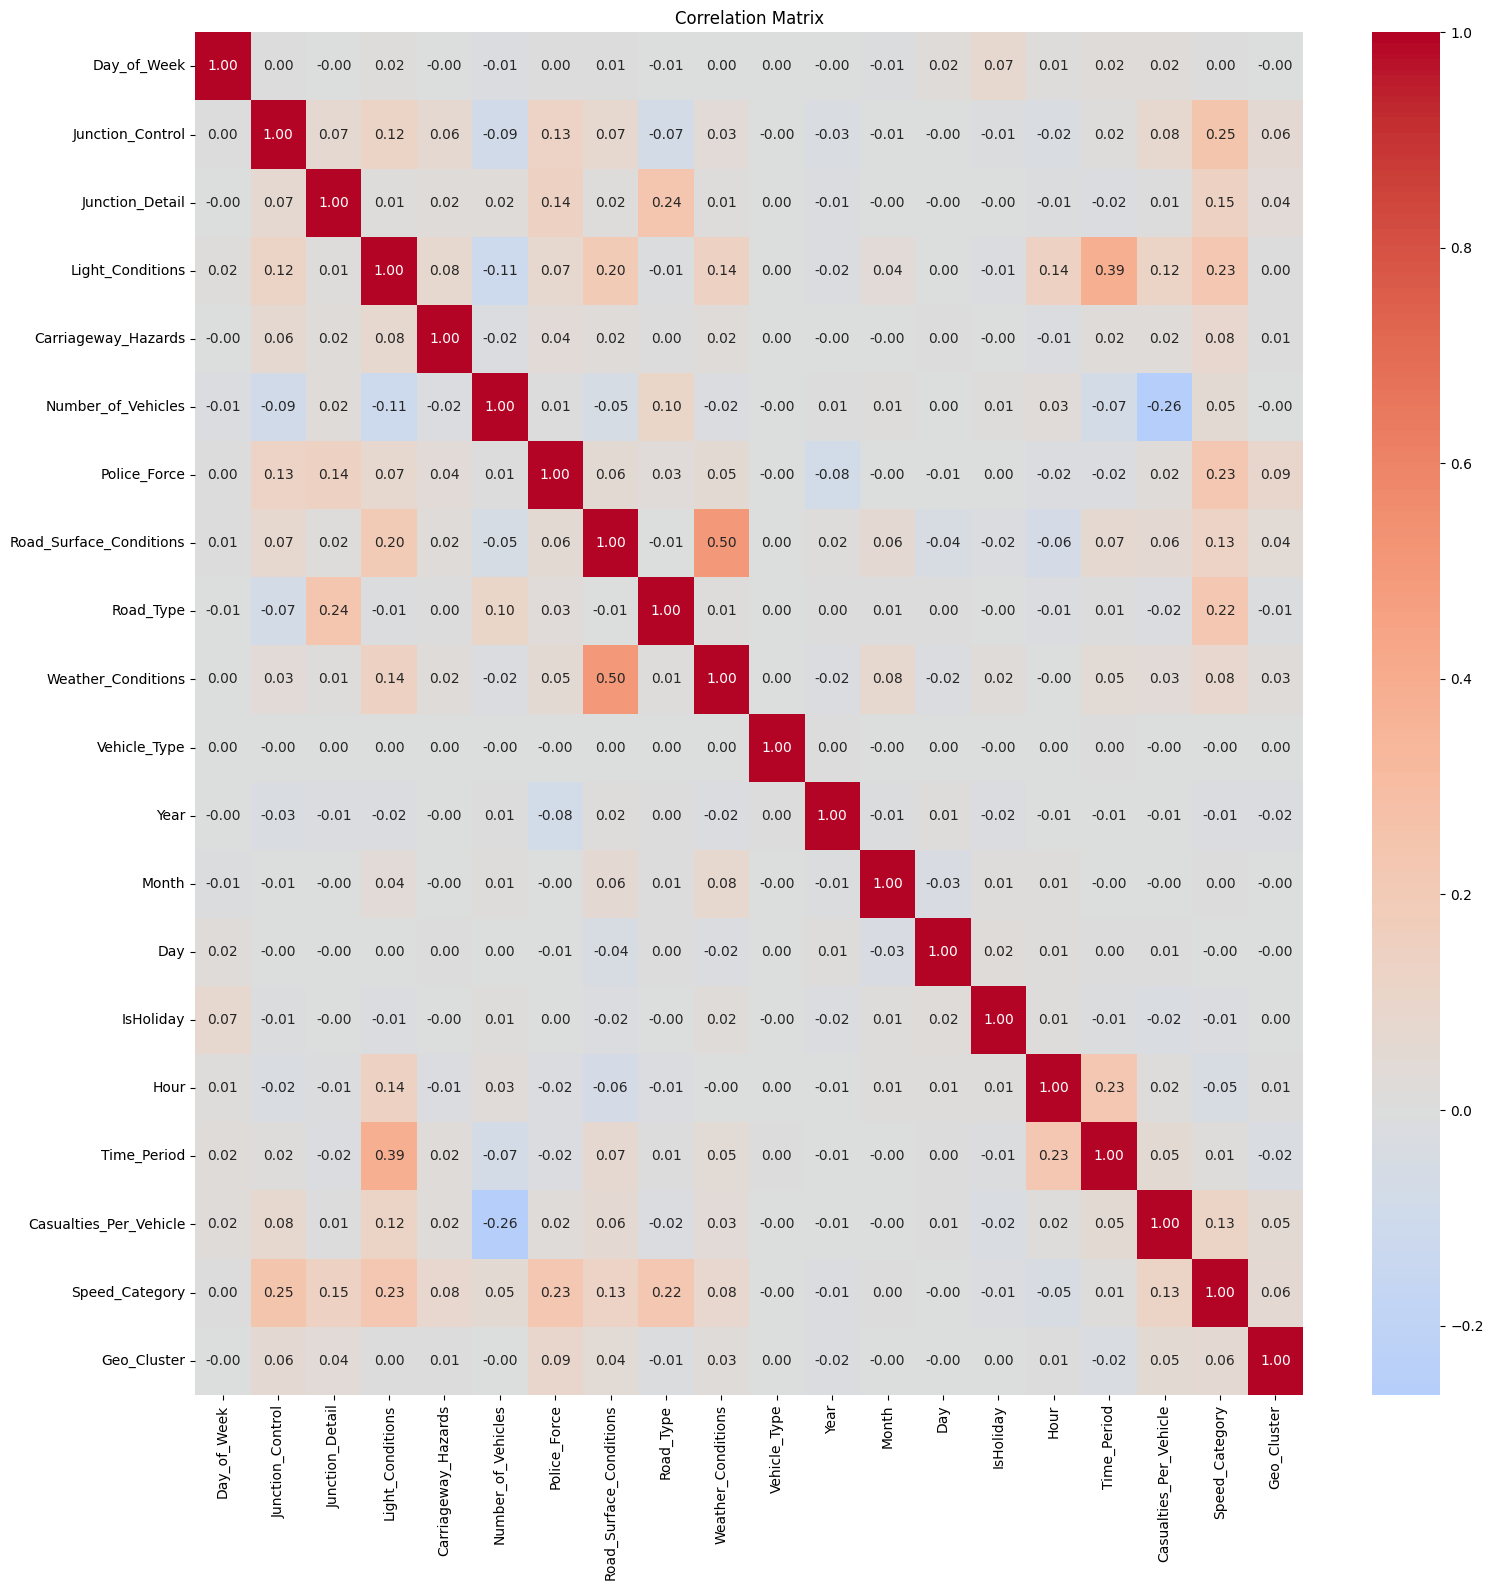

In [61]:
df.drop(['DayOfYear','WeekOfYear','Local_Authority_(District)','Urban_or_Rural_Area','IsWeekend','High_Casualty_Flag'],axis=1, inplace=True)
# Heatmap again after deleting redundant features
df_copy = df.copy()
df_copy.drop(['Accident_Severity'],axis=1, inplace=True)
df_copy = df.drop('Accident_Severity', axis=1).copy()
numerical_cols = df_copy.select_dtypes(include=['number']).columns
categorical_cols = df_copy.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    df_copy[col] = pd.factorize(df_copy[col])[0]
import seaborn as sns
print("CORRELATION MATRIX")
correlation_matrix = df_copy.corr()
plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
plt.close()

## Step 2: Feature Encoding

In [62]:
# Convert target to number
severity_map = {
    'Slight': 0,
    'Serious': 1,
    'Fatal': 2
}
df['Accident_Severity_Num'] = df['Accident_Severity'].map(severity_map)
df.drop('Accident_Severity',axis=1, inplace=True)

# Cyclical Encoding for Month, Day, and Hour
if 'Month' in df.columns:
    '''
    Months are "cyclic variables,"
    but continuous numerical models such as MLPs (Multilayer Perceptrons) may misinterpret this periodic relationship.
    Therefore, Cyclical Encoding is used to convert the Month feature into two new features: month_sin and month_cos.
    '''
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df.drop(['Month'], axis=1, inplace=True)


if 'Day' in df.columns:
    '''
    Day is not a "continuous numerical variable," but rather a "date variable with a cyclical pattern."
    Therefore, Cyclical Encoding is used to convert the Day feature into two new features: day_sin and day_cos.
    '''
    df['Day_Sin'] = np.sin(2 * np.pi * df['Day'] / 365)
    df['Day_Cos'] = np.cos(2 * np.pi * df['Day'] / 365)
    df.drop(['Day'], axis=1, inplace=True)

if 'Hour' in df.columns:
    '''
    Hour is not a "continuous numerical variable," but rather a "date variable with a cyclical pattern."
    Therefore, Cyclical Encoding is used to convert the Hour feature into two new features: hour_sin and hour_cos.
    '''
    df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
    df.drop(['Hour'], axis=1, inplace=True)

# Label encode features categorical features
if 'Urban_or_Rural_Area' in df.columns:
    # Label encode Urban_or_Rural_Area because 2 categories are reversed relationship
    urban_rural_map = {
        "Rural": 1,
        "Urban": 0
    }
    df['Urban_or_Rural_Area_label'] = df['Urban_or_Rural_Area'].map(urban_rural_map)
    df.drop('Urban_or_Rural_Area',axis=1, inplace=True)

if 'Day_of_Week' in df.columns:
    # Label encode Day_of_Week because 7 categories are ordinal relationship
    day_of_week_map = {
        "Monday": 0,
        "Tuesday": 1,
        "Wednesday": 2,
        "Thursday": 3,
        "Friday": 4,
        "Saturday": 5,
        "Sunday": 6
    }
    df['Day_of_Week_label'] = df['Day_of_Week'].map(day_of_week_map)
    df.drop('Day_of_Week',axis=1, inplace=True)

if 'IsHoliday' in df.columns:
    # label encode Is_Holiday because 2 categories are ordinal relationship
    # Convert to string first to ensure True/False are treated as strings, not booleans
    df['IsHoliday'] = df['IsHoliday'].astype(str)
    holiday_map = {
        "True": 1,
        "False": 0
    }
    df['IsHoliday_label'] = df['IsHoliday'].map(holiday_map)
    df.drop('IsHoliday', axis=1, inplace=True)

Label and Ont-hot

In [63]:
categorical_to_encode = df.select_dtypes(include=['object']).columns.tolist()
print(f"categorical_to_encode: {categorical_to_encode}")

# Label encode features with >10 unique values; add "_labeled", drop original
# Consider seven days of the week, so set nunique to 10 is reasonable
nunique_threshold = 10
cardinalities = [(col, df[col].nunique()) for col in categorical_to_encode]
for col in categorical_to_encode:
    nunique = df[col].nunique()
    if nunique > nunique_threshold:
        le = LabelEncoder()
        df[col + "_label"] = le.fit_transform(df[col].astype(str))
        df.drop(col, axis=1, inplace=True)
labeled_columns = [col for col, nunique in cardinalities if nunique > nunique_threshold]
print(f"\nFields labeled with LabelEncoder (nunique > {nunique_threshold}): {labeled_columns}")
remaining_unlabeled_cols = [col for col in df.columns if any(col == c for c, n in cardinalities if n <= nunique_threshold) and not col.endswith("_labeled")]


# One-hot encode features with cardinality <= nunique_threshold
for col in remaining_unlabeled_cols:
    # Get column names before one-hot encoding
    cols_before = set(df.columns)
    df = pd.get_dummies(df, columns=[col], dummy_na=False, dtype='uint8', drop_first=True)
    # Get newly created one-hot columns and rename them with "_on" suffix
    cols_after = set(df.columns)
    new_cols = cols_after - cols_before
    rename_dict = {col_name: col_name + "_on" for col_name in new_cols}
    df.rename(columns=rename_dict, inplace=True)
print(f"\nFields one-hot encoded (nunique <= {nunique_threshold}): {remaining_unlabeled_cols}")

# Check if all features have been successfully encoded to numeric types
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
if not non_numeric_cols:
    print("\nAll features have been successfully encoded to numeric types.")
else:
    print("\nWarning: There are still non-numeric columns remaining:")
    print(non_numeric_cols)

print(f"\nTotal number of columns: {len(df.columns)}")

categorical_to_encode: ['Junction_Control', 'Junction_Detail', 'Light_Conditions', 'Carriageway_Hazards', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Weather_Conditions', 'Vehicle_Type', 'Time_Period', 'Speed_Category']

Fields labeled with LabelEncoder (nunique > 10): ['Police_Force', 'Vehicle_Type']

Fields one-hot encoded (nunique <= 10): ['Junction_Control', 'Junction_Detail', 'Light_Conditions', 'Carriageway_Hazards', 'Road_Surface_Conditions', 'Road_Type', 'Weather_Conditions', 'Time_Period', 'Speed_Category']

All features have been successfully encoded to numeric types.

Total number of columns: 58


## Step 3: Split the dataset into 80% training and 20% testing

In [64]:
# split the dataset
from sklearn.model_selection import train_test_split
X = df.drop('Accident_Severity_Num', axis=1)
y = df['Accident_Severity_Num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Step 4: Feature selection

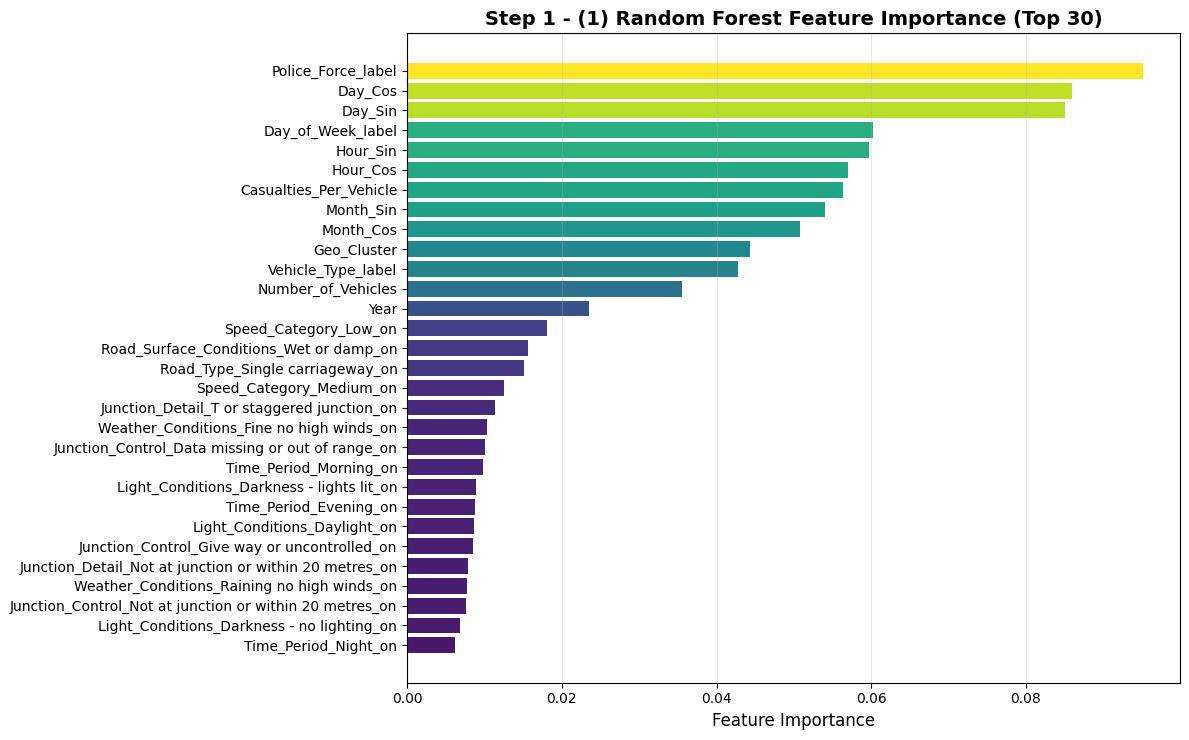

  Using sampled data for MI: 50000 samples (from 246376)


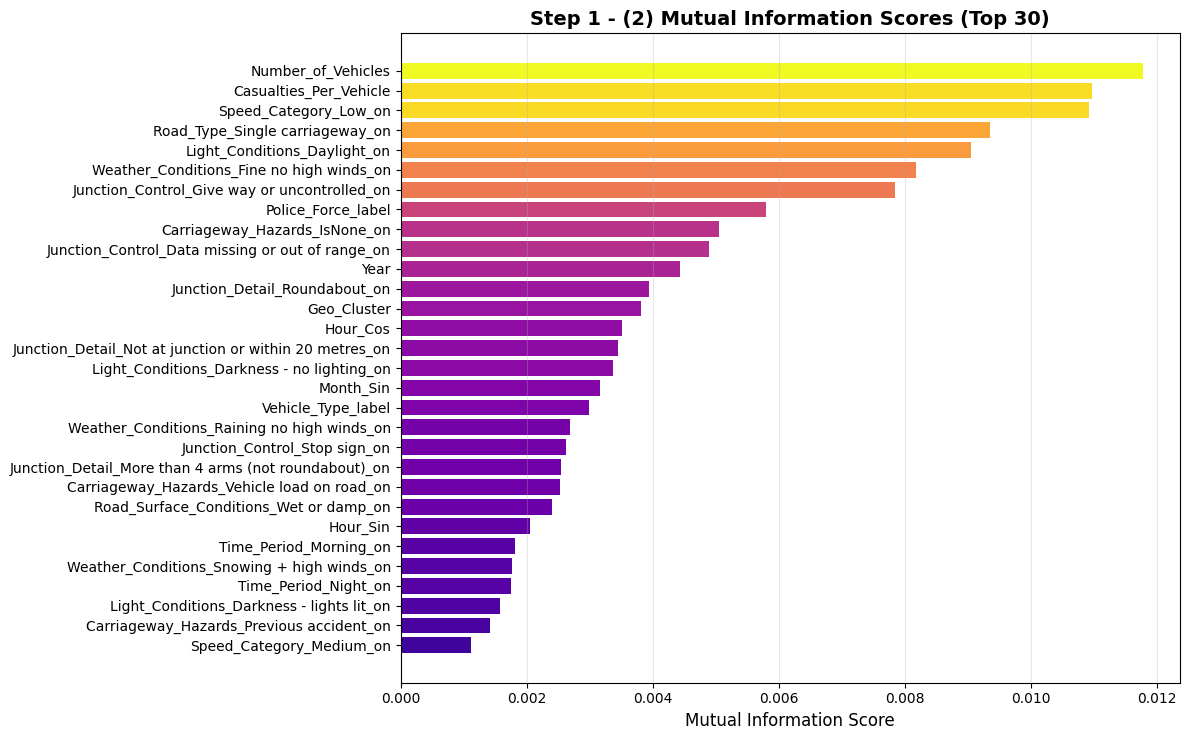

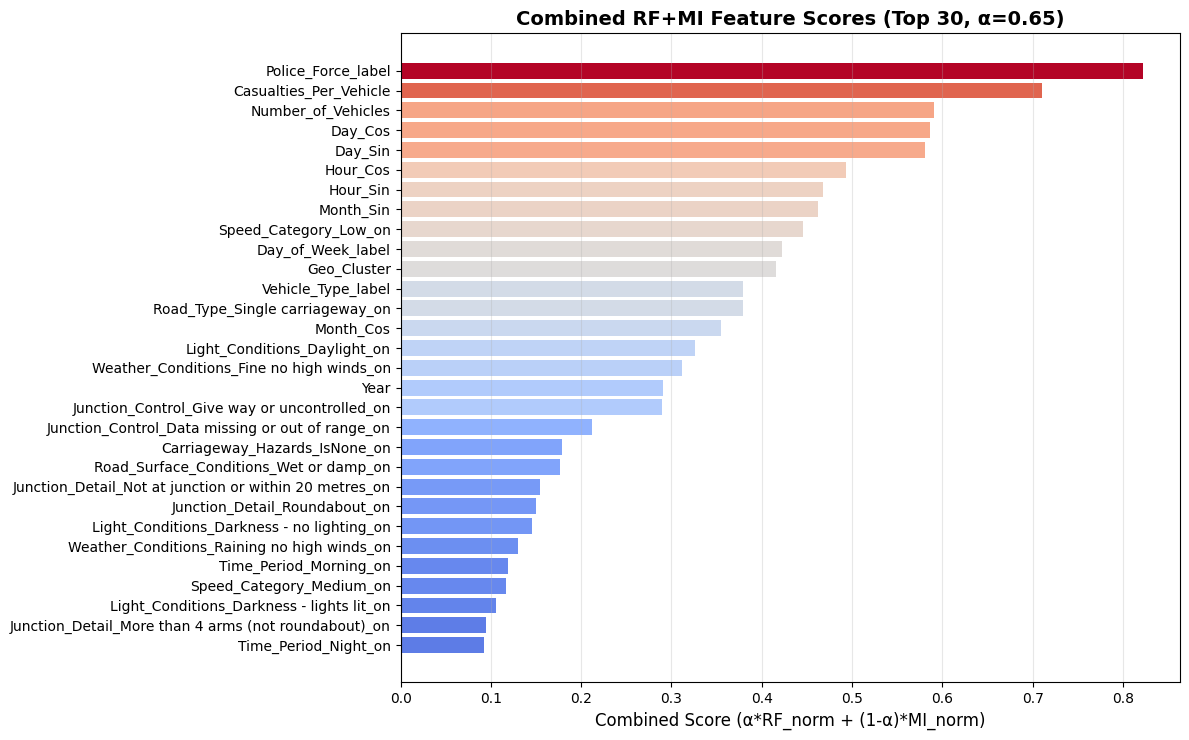


Top 35 features from Combined Score (RF + MI):
Continuing with remaining folds (stability not high enough)


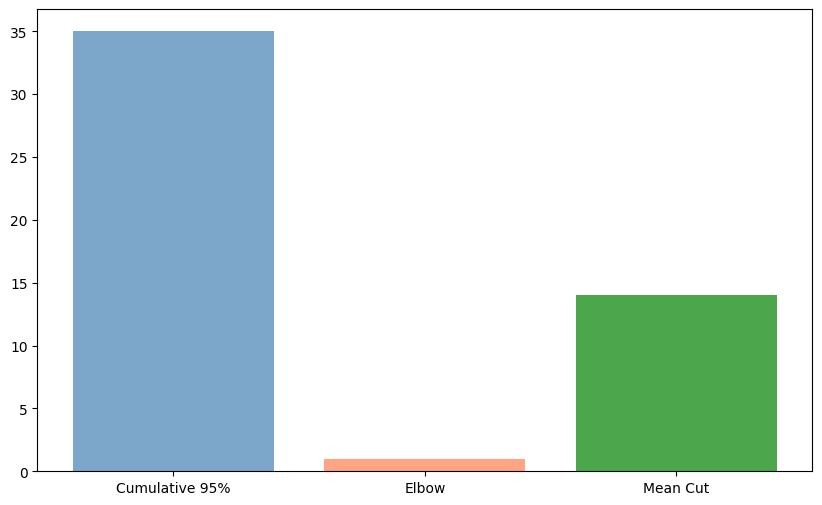

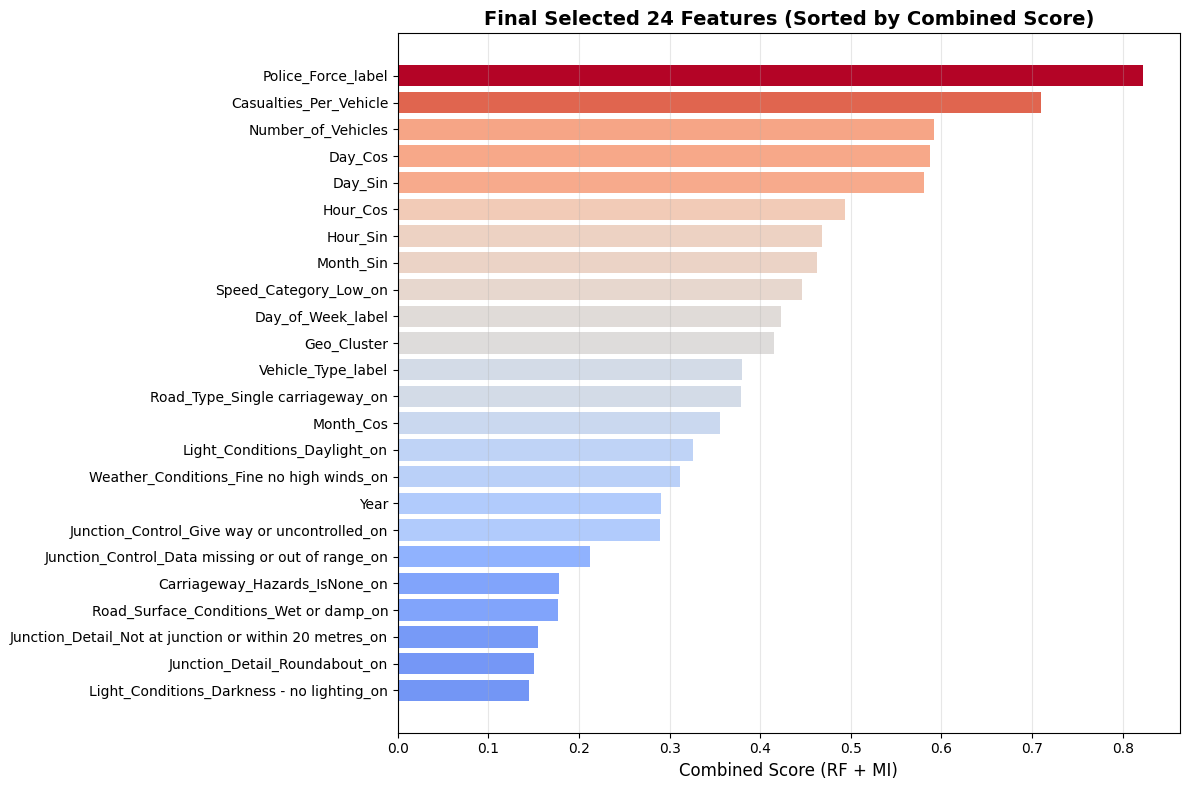

```
Final 24 features selected:

 1. Police_Force_label            
 2. Casualties_Per_Vehicle        
 3. Number_of_Vehicles            
 4. Day_Cos                       
 5. Day_Sin                       
 6. Hour_Cos                      
 7. Hour_Sin                      
 8. Month_Sin                     
 9. Speed_Category_Low_on         
10. Day_of_Week_label             
11. Geo_Cluster                   
12. Vehicle_Type_label            
13. Road_Type_Single carriageway_on
14. Month_Cos                     
15. Light_Conditions_Daylight_on  
16. Weather_Conditions_Fine no high winds_on
17. Year                          
18. Junction_Control_Give way or uncontrolled_on
19. Junction_Control_Data missing or out of range_on
20. Carriageway_Hazards_IsNone_on 
21. Road_Surface_Conditions_Wet or damp_on
22. Junction_Detail_Not at junction or within 20 metres_on
23. Junction_Detail_Roundabout_on 
24. Light_Conditions_Darkness - no lighting_on
```


Selected training dataframe shape: (246376, 24)
Selected test dataframe shape: (61595, 24)


In [ ]:
CONFIG = {
    'K_max': 40,
    'K_min': 15,
    'alpha': 0.65,
    'correlation_low': 0.02,
    'correlation_high': 0.90,
    'redundancy_threshold': 0.95,
    'cv_folds': 5,
    'cv_early_stop_jaccard': 0.95
}
df_x_train = X_train.copy()
df_x_test = X_test.copy()
target_col = 'Accident_Severity_Num'
df_y_train = y_train.to_frame().copy()
df_y_test = y_test.to_frame().copy()
y = df_y_train[target_col]

# Prepare features (X_train does not contain target column)
X = df_x_train.copy()

# Ensure all features are numeric
X_numeric = X.select_dtypes(include=[np.number]).copy()
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns
if len(non_numeric_cols) > 0:
    for i, col in enumerate(non_numeric_cols, 1):
        print(f"  {i:2d}. {col}")
    for col in non_numeric_cols:
        X_numeric[col] = pd.factorize(X[col])[0]
X_numeric = X_numeric.fillna(0)

# ============================================================================
# Step 1: Random Forest Feature Importance & Mutual Information
# ============================================================================
if len(X_numeric) > 100000:
    X_rf_sample, _, y_rf_sample, _ = train_test_split(
        X_numeric, y, train_size=100000, stratify=y, random_state=42
    )
else:
    X_rf_sample = X_numeric
    y_rf_sample = y
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=0, max_depth=20)
rf_model.fit(X_rf_sample, y_rf_sample)
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X_numeric.columns)
rf_feature_importances_sorted = rf_feature_importances.sort_values(ascending=False)
feature_importance_rf = pd.DataFrame({
    'Feature': rf_feature_importances_sorted.index,
    'Importance': rf_feature_importances_sorted.values
})
# Plot Random Forest feature importances
top_n_plot = min(30, len(rf_feature_importances_sorted))
plt.figure(figsize=(12, max(6, top_n_plot * 0.25)))
top_features_plot = rf_feature_importances_sorted.head(top_n_plot)
max_importance = top_features_plot.max()
colors = plt.cm.viridis(top_features_plot.values / max_importance if max_importance > 0 else top_features_plot.values)
plt.barh(range(len(top_features_plot)), top_features_plot.values, color=colors)
plt.yticks(range(len(top_features_plot)), top_features_plot.index)
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Step 1 - (1) Random Forest Feature Importance (Top {top_n_plot})', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()
if len(X_numeric) > 50000:
    X_mi_sample, _, y_mi_sample, _ = train_test_split(
        X_numeric, y, train_size=50000, stratify=y, random_state=42
    )
    print(f"  Using sampled data for MI: {len(X_mi_sample)} samples (from {len(X_numeric)})")
else:
    X_mi_sample = X_numeric
    y_mi_sample = y
mi_scores = mutual_info_classif(X_mi_sample, y_mi_sample, random_state=42, n_jobs=-1)
mi_feature_scores = pd.Series(mi_scores, index=X_numeric.columns)
mi_feature_scores_sorted = mi_feature_scores.sort_values(ascending=False)
feature_importance_mi = pd.DataFrame({
    'Feature': mi_feature_scores_sorted.index,
    'MI_Score': mi_feature_scores_sorted.values
})
# Plot Mutual Information scores
plt.figure(figsize=(12, max(6, top_n_plot * 0.25)))
top_mi_plot = mi_feature_scores_sorted.head(top_n_plot)
max_mi = top_mi_plot.max()
colors_mi = plt.cm.plasma(top_mi_plot.values / max_mi if max_mi > 0 else top_mi_plot.values)
plt.barh(range(len(top_mi_plot)), top_mi_plot.values, color=colors_mi)
plt.yticks(range(len(top_mi_plot)), top_mi_plot.index)
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title(f'Step 1 - (2) Mutual Information Scores (Top {top_n_plot})', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()

# ============================================================================
# Step 2: Three Methods to Determine K
# ============================================================================
# Method 1: Cumulative Importance Threshold
cumulative_importance = feature_importance_rf['Importance'].cumsum()
threshold_95 = 0.95  # Select features that explain 95% of importance
K_95 = (cumulative_importance <= threshold_95).sum() + 1
if K_95 > 0:
    actual_cumulative = cumulative_importance.iloc[K_95 - 1] if K_95 <= len(cumulative_importance) else cumulative_importance.iloc[-1]
# Method 2: Elbow method - find where importance drops significantly
importances = feature_importance_rf['Importance'].values
importance_diff = np.diff(importances)
elbow_point = np.argmax(importance_diff < np.percentile(importance_diff, 10)) + 1
# Method 3: Keep features with importance > mean importance
mean_importance = feature_importance_rf['Importance'].mean()
K_above_mean = (feature_importance_rf['Importance'] > mean_importance).sum()
K = K_95
K = max(CONFIG['K_min'], min(K, CONFIG['K_max']))

# ============================================================================
# Step 2.5: Combine RF and MI Scores with Normalization and Weighted Average
# ============================================================================
rf_scores = rf_feature_importances.values
rf_min, rf_max = rf_scores.min(), rf_scores.max()
rf_norm = (rf_scores - rf_min) / (rf_max - rf_min) if (rf_max - rf_min) > 0 else rf_scores
mi_scores_values = mi_feature_scores.values
mi_min, mi_max = mi_scores_values.min(), mi_scores_values.max()
mi_norm = (mi_scores_values - mi_min) / (mi_max - mi_min) if (mi_max - mi_min) > 0 else mi_scores_values
alpha = CONFIG['alpha']
final_scores = alpha * rf_norm + (1 - alpha) * mi_norm
combined_scores = pd.DataFrame({
    'Feature': X_numeric.columns,
    'RF_Score': rf_feature_importances.values,
    'MI_Score': mi_feature_scores.values,
    'RF_Score_Norm': rf_norm,
    'MI_Score_Norm': mi_norm,
    'Final_Score': final_scores
})
combined_scores_sorted = combined_scores.sort_values('Final_Score', ascending=False)
# Plot combined scores
plt.figure(figsize=(12, max(6, top_n_plot * 0.25)))
top_combined = combined_scores_sorted.head(top_n_plot)
max_combined = top_combined['Final_Score'].max()
colors_combined = plt.cm.coolwarm(top_combined['Final_Score'].values / max_combined if max_combined > 0 else top_combined['Final_Score'].values)
plt.barh(range(len(top_combined)), top_combined['Final_Score'].values, color=colors_combined)
plt.yticks(range(len(top_combined)), top_combined['Feature'].values)
plt.xlabel('Combined Score (α*RF_norm + (1-α)*MI_norm)', fontsize=12)
plt.title(f'Combined RF+MI Feature Scores (Top {top_n_plot}, α={alpha})', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()

# ============================================================================
# Step 3: Feature Selection with Combined Scores and Correlation Filtering
# ============================================================================
top_k_features = combined_scores_sorted['Feature'].head(K).tolist()
print(f"\nTop {K} features from Combined Score (RF + MI):")
for i, feat in enumerate(top_k_features, 1):
    row = combined_scores_sorted[combined_scores_sorted['Feature'] == feat].iloc[0]
target_corr_abs = X_numeric[top_k_features].corrwith(y).abs()
target_correlations = target_corr_abs.sort_values(ascending=False)
correlation_threshold_low = CONFIG['correlation_low']
correlation_threshold_high = CONFIG['correlation_high']
low_corr_features = target_corr_abs[target_corr_abs < correlation_threshold_low].index.tolist()
high_corr_features = target_corr_abs[target_corr_abs > correlation_threshold_high].index.tolist()
corr_removed = set(low_corr_features + high_corr_features)
remaining_features = [f for f in top_k_features if f not in corr_removed]
feature_corr_matrix = X_numeric[remaining_features].corr().abs()
redundancy_threshold = CONFIG['redundancy_threshold']
features_to_remove_redundancy = set()
for i, feat1 in enumerate(remaining_features):
    if feat1 in features_to_remove_redundancy:
        continue
    for feat2 in remaining_features[i+1:]:
        if feat2 in features_to_remove_redundancy:
            continue
        if feature_corr_matrix.loc[feat1, feat2] > redundancy_threshold:
            score1 = combined_scores_sorted[combined_scores_sorted['Feature'] == feat1]['Final_Score'].iloc[0]
            score2 = combined_scores_sorted[combined_scores_sorted['Feature'] == feat2]['Final_Score'].iloc[0]
            if score1 >= score2:
                features_to_remove_redundancy.add(feat2)
            else:
                features_to_remove_redundancy.add(feat1)
all_removed = corr_removed | features_to_remove_redundancy
final_features = [f for f in top_k_features if f not in all_removed]
min_features = max(10, int(K * 0.7))
if len(final_features) < min_features:
    final_features = combined_scores_sorted['Feature'].head(min_features).tolist()
# ============================================================================
# Step 3.5: Cross-Validation for Feature Stability Validation with Early Stopping
# ============================================================================
skf = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=42)
cv_feature_selections = []
early_stopped = False
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_numeric, y), 1):
    X_train_fold = X_numeric.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    if len(X_train_fold) > 100000:
        X_train_fold_sample, _, y_train_fold_sample, _ = train_test_split(
            X_train_fold, y_train_fold, train_size=100000, stratify=y_train_fold, random_state=42
        )
    else:
        X_train_fold_sample = X_train_fold
        y_train_fold_sample = y_train_fold
    rf_fold = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=0, max_depth=20)
    rf_fold.fit(X_train_fold_sample, y_train_fold_sample)
    rf_importances_fold = pd.Series(rf_fold.feature_importances_, index=X_numeric.columns)
    if len(X_train_fold) > 50000:
        X_mi_fold_sample, _, y_mi_fold_sample, _ = train_test_split(
            X_train_fold, y_train_fold, train_size=50000, stratify=y_train_fold, random_state=42
        )
    else:
        X_mi_fold_sample = X_train_fold
        y_mi_fold_sample = y_train_fold
    mi_scores_fold = mutual_info_classif(X_mi_fold_sample, y_mi_fold_sample, random_state=42, n_jobs=-1)
    mi_scores_fold_series = pd.Series(mi_scores_fold, index=X_numeric.columns)
    rf_fold_norm = (rf_importances_fold - rf_importances_fold.min()) / (rf_importances_fold.max() - rf_importances_fold.min()) if (rf_importances_fold.max() - rf_importances_fold.min()) > 0 else rf_importances_fold
    mi_fold_norm = (mi_scores_fold_series - mi_scores_fold_series.min()) / (mi_scores_fold_series.max() - mi_scores_fold_series.min()) if (mi_scores_fold_series.max() - mi_scores_fold_series.min()) > 0 else mi_scores_fold_series
    combined_fold = alpha * rf_fold_norm + (1 - alpha) * mi_fold_norm
    combined_fold_sorted = pd.Series(combined_fold, index=X_numeric.columns).sort_values(ascending=False)
    top_k_fold = combined_fold_sorted.head(K).index.tolist()
    cv_feature_selections.append(set(top_k_fold))
    if fold_idx == 3 and len(cv_feature_selections) == 3:
        jaccard_scores_3fold = []
        for i in range(3):
            for j in range(i+1, 3):
                intersection = len(cv_feature_selections[i] & cv_feature_selections[j])
                union = len(cv_feature_selections[i] | cv_feature_selections[j])
                jaccard = intersection / union if union > 0 else 0
                jaccard_scores_3fold.append(jaccard)

        mean_jaccard_3fold = np.mean(jaccard_scores_3fold)
        min_jaccard_3fold = np.min(jaccard_scores_3fold)
        if mean_jaccard_3fold >= CONFIG['cv_early_stop_jaccard'] and min_jaccard_3fold >= CONFIG['cv_early_stop_jaccard']:
            early_stopped = True
            break
        else:
            print(f"Continuing with remaining folds (stability not high enough)")
n_folds_completed = len(cv_feature_selections)
if early_stopped:
    print(f"Note: Early stopping was triggered after {n_folds_completed} folds")
features_in_all_folds = set.intersection(*cv_feature_selections) if cv_feature_selections else set()
threshold_folds = max(1, n_folds_completed - 1)
features_in_threshold_folds = set()
for feat in set.union(*cv_feature_selections) if cv_feature_selections else set():
    count = sum(1 for fold_features in cv_feature_selections if feat in fold_features)
    if count >= threshold_folds:
        features_in_threshold_folds.add(feat)
if features_in_threshold_folds:
    for i, feat in enumerate(sorted(features_in_threshold_folds), 1):
        count = sum(1 for fold_features in cv_feature_selections if feat in fold_features)
jaccard_similarities = []
for i in range(n_folds_completed):
    for j in range(i+1, n_folds_completed):
        intersection = len(cv_feature_selections[i] & cv_feature_selections[j])
        union = len(cv_feature_selections[i] | cv_feature_selections[j])
        jaccard = intersection / union if union > 0 else 0
        jaccard_similarities.append(jaccard)
if jaccard_similarities:
    mean_jaccard = np.mean(jaccard_similarities)
    std_jaccard = np.std(jaccard_similarities)
else:
    mean_jaccard = 0.0
    print(f"\nJaccard Similarity: Not enough folds to calculate")
final_features_set = set(final_features)
overlap_with_final = len(final_features_set & features_in_all_folds)
overlap_ratio = overlap_with_final / len(final_features) if len(final_features) > 0 else 0

# ============================================================================
# Step 4: Visualization and Save
# ============================================================================
# Plot 1: K selection methods comparison
plt.figure(figsize=(10, 6))
methods = ['Cumulative 95%', 'Elbow', 'Mean Cut']
k_values = [K_95, elbow_point, K_above_mean]
colors_plot = ['steelblue', 'coral', 'green']
bars = plt.bar(methods, k_values, color=colors_plot, alpha=0.7)

# Plot 2: Final selected features sorted by combined score
plt.figure(figsize=(12, max(8, len(final_features) * 0.3)))
final_combined_scores = combined_scores_sorted[combined_scores_sorted['Feature'].isin(final_features)].sort_values('Final_Score', ascending=False)
max_score = final_combined_scores['Final_Score'].max()
colors_final = plt.cm.coolwarm(final_combined_scores['Final_Score'].values / max_score if max_score > 0 else final_combined_scores['Final_Score'].values)
plt.barh(range(len(final_features)), final_combined_scores['Final_Score'].values, color=colors_final)
plt.yticks(range(len(final_features)), final_combined_scores['Feature'].values)
plt.xlabel('Combined Score (RF + MI)', fontsize=12)
plt.title(f'Final Selected {len(final_features)} Features (Sorted by Combined Score)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()

lines = []
lines.append(f"Final {len(final_features)} features selected:\n")

for i, feat in enumerate(final_features, 1):
    row = combined_scores_sorted[combined_scores_sorted['Feature'] == feat].iloc[0]
    target_corr = X_numeric[feat].corr(y)
    lines.append(f"{i:2d}. {feat:30s}")
md_text = "```\n" + "\n".join(lines) + "\n```"
display(Markdown(md_text))


# Create selected dataframe for training set
selected_df_x_train = df_x_train[final_features]
print(f"\nSelected training dataframe shape: {selected_df_x_train.shape}")

# Create selected dataframe for test set (apply same feature selection)
selected_df_x_test = df_x_test[final_features]
print(f"Selected test dataframe shape: {selected_df_x_test.shape}")


Scale data

In [66]:
# Scale the data to prevent dominance and improve performance, use standard scaler
print("\nScaling data...")
scaler = StandardScaler()
scaler.fit(selected_df_x_train)
X_train_scaled = scaler.transform(selected_df_x_train)
X_test = scaler.transform(selected_df_x_test)



Scaling data...


# Train Model

AGGRESSIVE SAMPLING STRATEGY: ADASYN + RANDOM UNDER SAMPLING

In [67]:
# Check class distribution
print("\nClass Distribution (Training Set):")
train_dist = y_train.value_counts().sort_index()
for cls, count in train_dist.items():
    pct = count / len(y_train) * 100
    print(f"  Class {cls}: {count:6d} ({pct:5.2f}%)")

print("\nClass Distribution (Test Set):")
test_dist = y_test.value_counts().sort_index()
for cls, count in test_dist.items():
    pct = count / len(y_test) * 100
    print(f"  Class {cls}: {count:6d} ({pct:5.2f}%)")

# Get majority class count
majority_count = train_dist.max()
print(f"Majority class (Class 0) count: {majority_count:,}")

# Step 1: Use ADASYN (better than SMOTE for hard-to-learn samples)
print("\nStep 1: Using ADASYN for better minority class synthesis...")
adasyn = ADASYN(
    sampling_strategy={
        1: int(majority_count * 0.30),
        2: int(majority_count * 0.15)
    },
    n_neighbors=2,
    random_state=42
)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

print("\nAfter ADASYN:")
adasyn_dist = pd.Series(y_adasyn).value_counts().sort_index()
for cls, count in adasyn_dist.items():
    pct = count / len(y_adasyn) * 100
    print(f"  Class {cls}: {count:6d} ({pct:5.2f}%)")

# Step 2: Moderate undersampling of majority class
print("\nStep 2: Moderate undersampling of majority class...")
rus = RandomUnderSampler(
    sampling_strategy={0: int(majority_count * 0.55)},
    random_state=42
)
X_train_final, y_train_final = rus.fit_resample(X_adasyn, y_adasyn)

print("\nFinal training set distribution:")
final_dist = pd.Series(y_train_final).value_counts().sort_index()
for cls, count in final_dist.items():
    pct = count / len(y_train_final) * 100
    print(f"  Class {cls}: {count:6d} ({pct:5.2f}%)")

print(f"\nTraining set size: {len(X_train_scaled):,} -> {len(X_train_final):,}")
print(f"Test set size: {len(X_test):,} samples (unchanged)")

# Use final balanced data for training
X_train = X_train_final
y_train = y_train_final


Class Distribution (Training Set):
  Class 0: 210622 (85.49%)
  Class 1:  32592 (13.23%)
  Class 2:   3162 ( 1.28%)

Class Distribution (Test Set):
  Class 0:  52656 (85.49%)
  Class 1:   8148 (13.23%)
  Class 2:    791 ( 1.28%)
Majority class (Class 0) count: 210,622

Step 1: Using ADASYN for better minority class synthesis...

After ADASYN:
  Class 0: 210622 (68.95%)
  Class 1:  64165 (21.00%)
  Class 2:  30695 (10.05%)

Step 2: Moderate undersampling of majority class...

Final training set distribution:
  Class 0: 115842 (54.98%)
  Class 1:  64165 (30.45%)
  Class 2:  30695 (14.57%)

Training set size: 246,376 -> 210,702
Test set size: 61,595 samples (unchanged)


COMPUTE CLASS WEIGHTS FOR OTHER MODELS (RF, XGBoost)

In [68]:
# Compute class weights for RandomForest and XGBoost
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"\nClass weights: {class_weight_dict}")
for cls, weight in class_weight_dict.items():
    count = (y_train == cls).sum()
    print(f"  Class {cls}: {count:6d} samples -> weight: {weight:.4f}")

# Compute sample weights for XGBoost
sample_weights = compute_sample_weight('balanced', y_train)
print(f"\nSample weights computed for {len(sample_weights):,} training samples (for XGBoost)")


Class weights: {np.int64(0): np.float64(0.6062913278430966), np.int64(1): np.float64(1.0945842749162316), np.int64(2): np.float64(2.288125101808112)}
  Class 0: 115842 samples -> weight: 0.6063
  Class 1:  64165 samples -> weight: 1.0946
  Class 2:  30695 samples -> weight: 2.2881

Sample weights computed for 210,702 training samples (for XGBoost)


PART 1: BASELINE MLP MODEL

In [69]:
# Baseline MLP model
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)
mlp_baseline.fit(X_train, y_train)

baseline_eval_start = time.time()
y_train_pred_baseline = mlp_baseline.predict(X_train)
y_train_proba_baseline = mlp_baseline.predict_proba(X_train)
y_test_pred_baseline = mlp_baseline.predict(X_test)
y_test_proba_baseline = mlp_baseline.predict_proba(X_test)
baseline_train_acc = accuracy_score(y_train, y_train_pred_baseline)
baseline_test_acc = accuracy_score(y_test, y_test_pred_baseline)
baseline_test_precision = precision_score(y_test, y_test_pred_baseline, average='macro', zero_division=0)
baseline_test_recall = recall_score(y_test, y_test_pred_baseline, average='macro', zero_division=0)
baseline_train_f1 = f1_score(y_train, y_train_pred_baseline, average='macro', zero_division=0)
baseline_test_f1 = f1_score(y_test, y_test_pred_baseline, average='macro', zero_division=0)
baseline_test_auc = roc_auc_score(y_test, y_test_proba_baseline, multi_class='ovr', average='macro')
print(f"Baseline MLP - Training F1-Score: {baseline_train_f1:.4f} (Accuracy: {baseline_train_acc:.4f})")
print(f"Baseline MLP - Test F1-Score: {baseline_test_f1:.4f} (Accuracy: {baseline_test_acc:.4f})")

Baseline MLP - Training F1-Score: 0.6547 (Accuracy: 0.6878)
Baseline MLP - Test F1-Score: 0.3776 (Accuracy: 0.7691)


PART 2: HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV

In [70]:
mlp_param_dist = {
    'hidden_layer_sizes': [(100, 50), (128, 64), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01],
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam']
}
base_mlp = MLPClassifier(
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)
mlp_random_search = RandomizedSearchCV(
    estimator=base_mlp,
    param_distributions=mlp_param_dist,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
mlp_random_search.fit(X_train, y_train)
mlp_tuned = mlp_random_search.best_estimator_
tuned_eval_start = time.time()
y_train_pred_tuned = mlp_tuned.predict(X_train)
y_train_proba_tuned = mlp_tuned.predict_proba(X_train)
y_test_pred_tuned = mlp_tuned.predict(X_test)
y_test_proba_tuned = mlp_tuned.predict_proba(X_test)
tuned_train_acc = accuracy_score(y_train, y_train_pred_tuned)
tuned_test_acc = accuracy_score(y_test, y_test_pred_tuned)
tuned_test_precision = precision_score(y_test, y_test_pred_tuned, average='macro', zero_division=0)
tuned_test_recall = recall_score(y_test, y_test_pred_tuned, average='macro', zero_division=0)
tuned_train_f1 = f1_score(y_train, y_train_pred_tuned, average='macro', zero_division=0)
tuned_test_f1 = f1_score(y_test, y_test_pred_tuned, average='macro', zero_division=0)
tuned_test_auc = roc_auc_score(y_test, y_test_proba_tuned, multi_class='ovr', average='macro')

print(f"Tuned MLP - Training F1-Score: {tuned_train_f1:.4f} (Accuracy: {tuned_train_acc:.4f})")
print(f"Tuned MLP - Test F1-Score: {tuned_test_f1:.4f} (Accuracy: {tuned_test_acc:.4f})")
tuned_f1_diff = tuned_test_f1 - baseline_test_f1
tuned_f1_pct = (tuned_f1_diff / baseline_test_f1 * 100) if baseline_test_f1 > 0 else 0
print(f"F1-Score Improvement: {tuned_f1_diff:+.4f} ({tuned_f1_pct:+.2f}%) (Accuracy Improvement: {tuned_test_acc - baseline_test_acc:+.4f})")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuned MLP - Training F1-Score: 0.6760 (Accuracy: 0.7040)
Tuned MLP - Test F1-Score: 0.3729 (Accuracy: 0.7705)
F1-Score Improvement: -0.0047 (-1.25%) (Accuracy Improvement: +0.0015)


PART 3: ENSEMBLE METHODS

In [71]:
# ============================================================================
# THRESHOLD ADJUSTED CLASSIFIER WRAPPER
# ============================================================================
class ThresholdAdjustedClassifier:
    """
    Wrapper class: Adjust prediction thresholds for Class 2 to improve recall.
    Uses lower threshold for Class 2 to increase recall for minority class.
    """
    def __init__(self, base_estimator, class_2_threshold=0.15, class_1_threshold=0.25):
        self.base_estimator = base_estimator
        self.class_2_threshold = class_2_threshold
        self.class_1_threshold = class_1_threshold

    def fit(self, X, y):
        self.base_estimator.fit(X, y)
        return self

    def predict(self, X):
        probas = self.base_estimator.predict_proba(X)
        predictions = np.argmax(probas, axis=1)

        # Apply threshold adjustment for Class 2 (lower threshold = higher recall)
        for i in range(len(probas)):
            if probas[i, 2] > self.class_2_threshold:
                predictions[i] = 2
            elif probas[i, 1] > self.class_1_threshold:
                predictions[i] = 1

        return predictions

    def predict_proba(self, X):
        return self.base_estimator.predict_proba(X)

# ============================================================================
# FUNCTION: FIND BEST THRESHOLDS
# ============================================================================
def find_best_thresholds(model, X_val, y_val):
    """
    Grid search to find optimal threshold combination for Class 2 and Class 1.
    Returns best thresholds (class_2_threshold, class_1_threshold) and best F1 score.
    """
    probas = model.predict_proba(X_val)
    best_f1 = 0
    best_thresholds = (0.15, 0.25)

    print("\nSearching for optimal thresholds...")
    for t2 in np.arange(0.05, 0.30, 0.05):  # Class 2 threshold range
        for t1 in np.arange(0.15, 0.40, 0.05):  # Class 1 threshold range
            preds = np.argmax(probas, axis=1).copy()
            for i in range(len(probas)):
                if probas[i, 2] > t2:
                    preds[i] = 2
                elif probas[i, 1] > t1:
                    preds[i] = 1

            f1 = f1_score(y_val, preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresholds = (t2, t1)

    print(f"Best thresholds: Class 2={best_thresholds[0]:.2f}, Class 1={best_thresholds[1]:.2f}")
    print(f"Best F1-Score: {best_f1:.4f}")
    return best_thresholds, best_f1

# ============================================================================
# Ensemble Method 1: Balanced Bagging Classifier
# ============================================================================
bagging_mlp = BalancedBaggingClassifier(
    estimator=MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10,
        verbose=False
    ),
    n_estimators=7,
    sampling_strategy='auto',
    replacement=False,
    random_state=42,
    n_jobs=-1
)
bagging_mlp.fit(X_train, y_train)
bagging_eval_start = time.time()
y_train_pred_bagging = bagging_mlp.predict(X_train)
y_train_proba_bagging = bagging_mlp.predict_proba(X_train)
y_test_pred_bagging = bagging_mlp.predict(X_test)
y_test_proba_bagging = bagging_mlp.predict_proba(X_test)
bagging_train_acc = accuracy_score(y_train, y_train_pred_bagging)
bagging_test_acc = accuracy_score(y_test, y_test_pred_bagging)
bagging_test_precision = precision_score(y_test, y_test_pred_bagging, average='macro', zero_division=0)
bagging_test_recall = recall_score(y_test, y_test_pred_bagging, average='macro', zero_division=0)
bagging_train_f1 = f1_score(y_train, y_train_pred_bagging, average='macro', zero_division=0)
bagging_test_f1 = f1_score(y_test, y_test_pred_bagging, average='macro', zero_division=0)
bagging_test_f1_weighted = f1_score(y_test, y_test_pred_bagging, average='weighted', zero_division=0)
bagging_test_f1_per_class = f1_score(y_test, y_test_pred_bagging, average=None, zero_division=0)
bagging_test_auc = roc_auc_score(y_test, y_test_proba_bagging, multi_class='ovr', average='macro')
bagging_f1_diff = bagging_test_f1 - baseline_test_f1
bagging_f1_pct = (bagging_f1_diff / baseline_test_f1 * 100) if baseline_test_f1 > 0 else 0

# ============================================================================
# Ensemble Method 2: Voting Classifier (Heterogeneous Models)
# ============================================================================
class PretrainedMLPWrapper:
    """
    Wrapper class to prevent VotingClassifier from retraining an already trained MLP.
    This allows us to reuse mlp_tuned in VotingClassifier without retraining.
    Compatible with sklearn's VotingClassifier and works in Google Colab.
    """
    def __init__(self, pretrained_model):
        self.pretrained_model = pretrained_model
        if hasattr(pretrained_model, '_is_fitted'):
            self._is_fitted = pretrained_model._is_fitted
        else:
            self._is_fitted = True

    def fit(self, X, y):
        # Skip training since model is already trained
        # Just return self to satisfy VotingClassifier's fit() call
        return self

    def predict(self, X):
        return self.pretrained_model.predict(X)

    def predict_proba(self, X):
        return self.pretrained_model.predict_proba(X)

    def get_params(self, deep=True):
        return self.pretrained_model.get_params(deep=deep)

    def set_params(self, **params):
        self.pretrained_model.set_params(**params)
        return self

    def __getattr__(self, name):
        return getattr(self.pretrained_model, name)
mlp_for_voting = PretrainedMLPWrapper(mlp_tuned)
rf_for_voting = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1, 
    class_weight='balanced'
)
rf_for_voting.fit(X_train, y_train)
y_test_pred_rf = rf_for_voting.predict(X_test)
rf_test_f1 = f1_score(y_test, y_test_pred_rf, average='macro', zero_division=0)
rf_test_acc = accuracy_score(y_test, y_test_pred_rf)
xgb_voting_start = time.time()
xgb_for_voting = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1
)
xgb_for_voting.fit(X_train, y_train, sample_weight=sample_weights)
y_test_pred_xgb = xgb_for_voting.predict(X_test)
xgb_test_f1 = f1_score(y_test, y_test_pred_xgb, average='macro', zero_division=0)
xgb_test_acc = accuracy_score(y_test, y_test_pred_xgb)
voting_setup_start = time.time()
voting_clf = VotingClassifier(
    estimators=[
        ('mlp', mlp_for_voting),
        ('rf', rf_for_voting),
        ('xgb', xgb_for_voting)
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
voting_setup_time = time.time() - voting_setup_start
voting_eval_start = time.time()
y_train_pred_voting = voting_clf.predict(X_train)
y_train_proba_voting = voting_clf.predict_proba(X_train)
y_test_pred_voting = voting_clf.predict(X_test)
y_test_proba_voting = voting_clf.predict_proba(X_test)
voting_train_acc = accuracy_score(y_train, y_train_pred_voting)
voting_test_acc = accuracy_score(y_test, y_test_pred_voting)
voting_test_precision = precision_score(y_test, y_test_pred_voting, average='macro', zero_division=0)
voting_test_recall = recall_score(y_test, y_test_pred_voting, average='macro', zero_division=0)
voting_train_f1 = f1_score(y_train, y_train_pred_voting, average='macro', zero_division=0)
voting_test_f1 = f1_score(y_test, y_test_pred_voting, average='macro', zero_division=0)
voting_test_auc = roc_auc_score(y_test, y_test_proba_voting, multi_class='ovr', average='macro')
voting_f1_diff = voting_test_f1 - baseline_test_f1
voting_f1_pct = (voting_f1_diff / baseline_test_f1 * 100) if baseline_test_f1 > 0 else 0

# ============================================================================
# MODEL COMPARISON (ALL METRICS)
# ============================================================================
models = {
    'Baseline MLP': {
        'model': mlp_baseline,
        'y_train_pred': y_train_pred_baseline,
        'y_train_proba': y_train_proba_baseline,
        'y_test_pred': y_test_pred_baseline,
        'y_test_proba': y_test_proba_baseline
    },
    'Tuned MLP': {
        'model': mlp_tuned,
        'y_train_pred': y_train_pred_tuned,
        'y_train_proba': y_train_proba_tuned,
        'y_test_pred': y_test_pred_tuned,
        'y_test_proba': y_test_proba_tuned
    },
    'Bagging MLP': {
        'model': bagging_mlp,
        'y_train_pred': y_train_pred_bagging,
        'y_train_proba': y_train_proba_bagging,
        'y_test_pred': y_test_pred_bagging,
        'y_test_proba': y_test_proba_bagging
    },
    'Voting Ensemble': {
        'model': voting_clf,
        'y_train_pred': y_train_pred_voting,
        'y_train_proba': y_train_proba_voting,
        'y_test_pred': y_test_pred_voting,
        'y_test_proba': y_test_proba_voting
    }
}
results_df = pd.DataFrame({
    'Model': ['Baseline MLP', 'Tuned MLP', 'Bagging MLP', 'Voting Ensemble'],
    'Accuracy': [baseline_test_acc, tuned_test_acc, bagging_test_acc, voting_test_acc],
    'Precision': [baseline_test_precision, tuned_test_precision, bagging_test_precision, voting_test_precision],
    'Recall': [baseline_test_recall, tuned_test_recall, bagging_test_recall, voting_test_recall],
    'F1-Score': [baseline_test_f1, tuned_test_f1, bagging_test_f1, voting_test_f1],
    'AUC': [baseline_test_auc, tuned_test_auc, bagging_test_auc, voting_test_auc]
})

# Display comprehensive comparison table
print("\nMODEL COMPARISON SUMMARY:")
print("="*80)
cols_order = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
results_df_ordered = results_df[cols_order]
print(results_df_ordered.to_string(index=False))


MODEL COMPARISON SUMMARY:
          Model  Accuracy  Precision   Recall  F1-Score      AUC
   Baseline MLP  0.769072   0.378510 0.387615  0.377606 0.628228
      Tuned MLP  0.770550   0.374564 0.380063  0.372878 0.617431
    Bagging MLP  0.589723   0.374818 0.424434  0.352917 0.642086
Voting Ensemble  0.822404   0.399714 0.375557  0.375045 0.679246


PART 4: Use accuracy, precision, recall, F1, and AUC to evaluate models

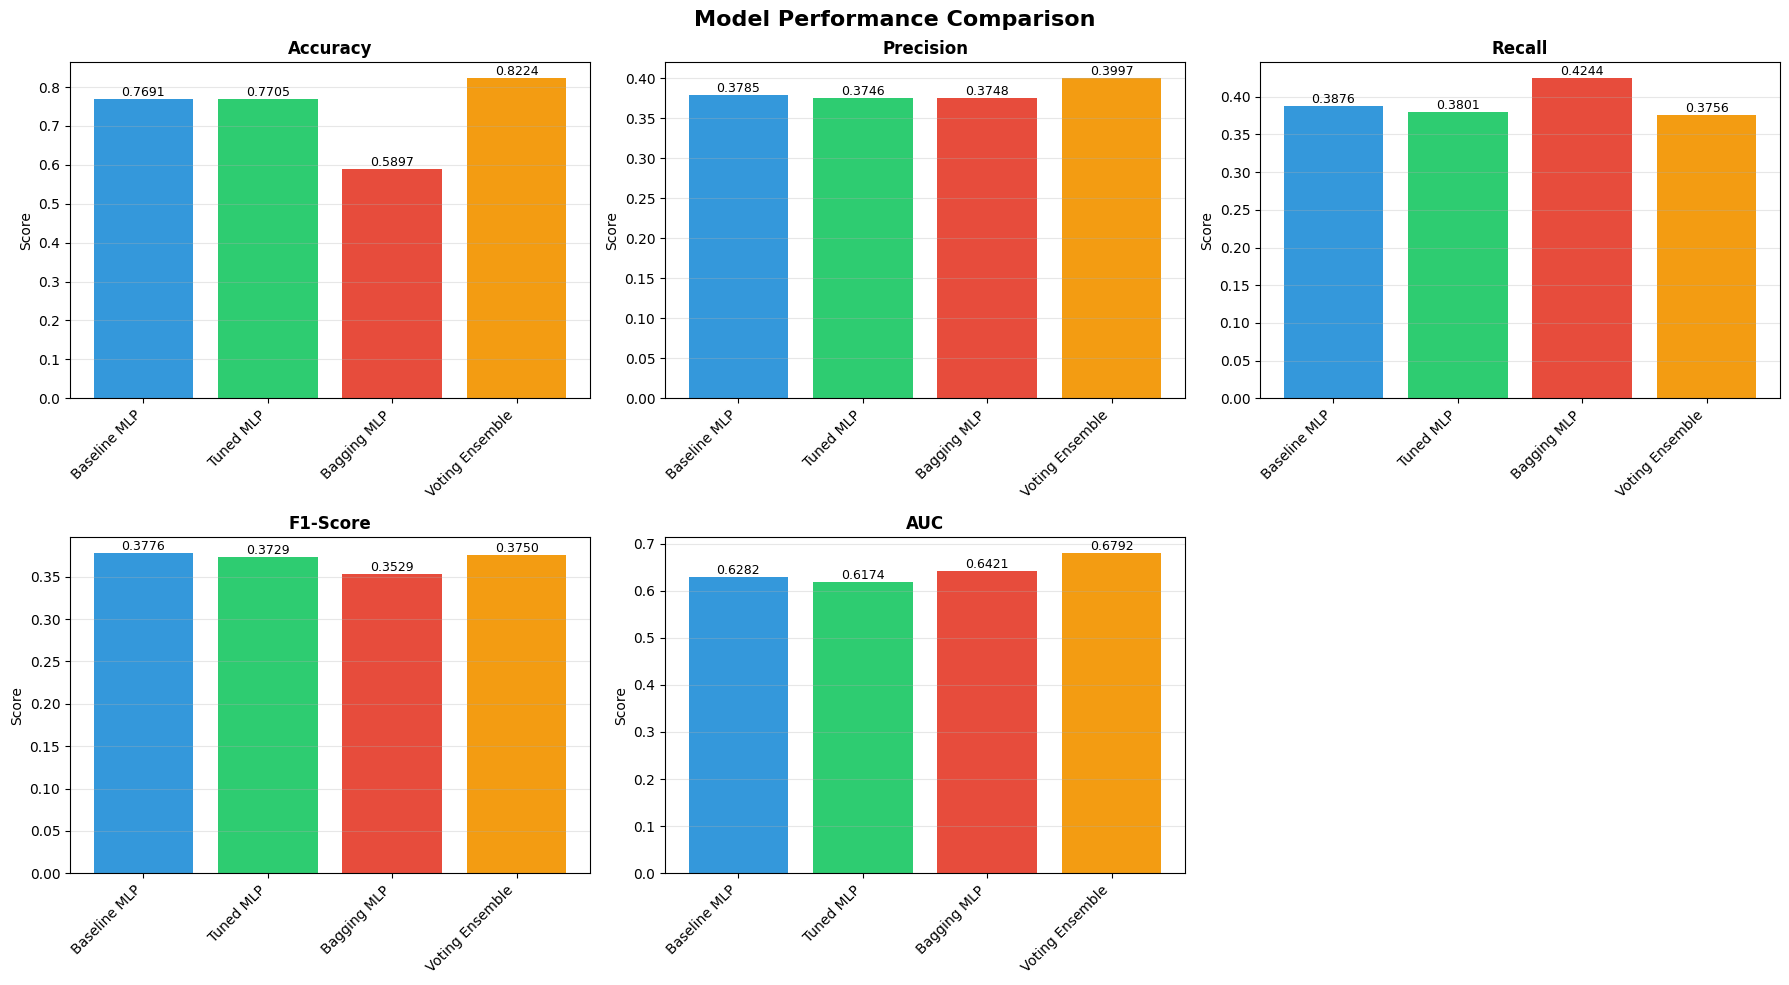

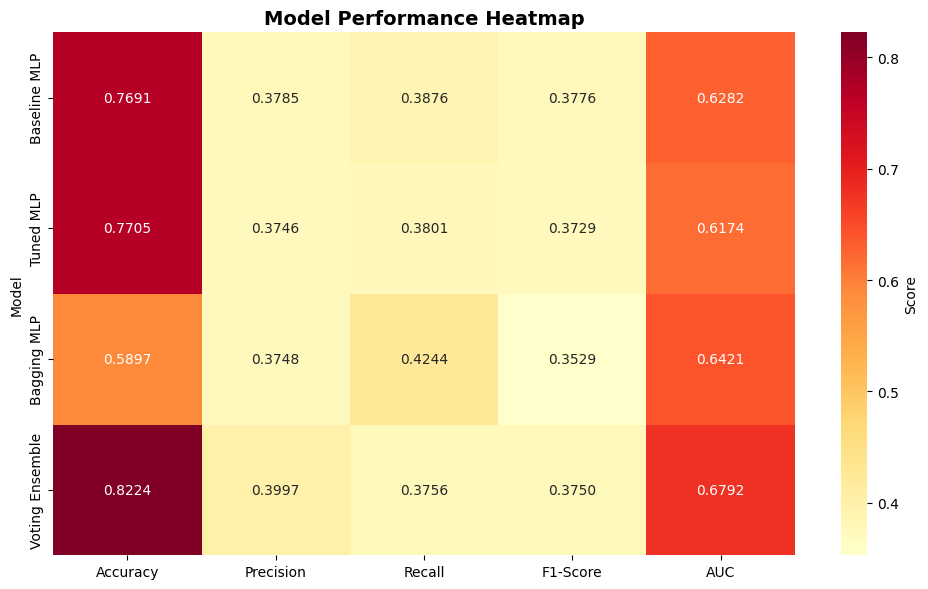

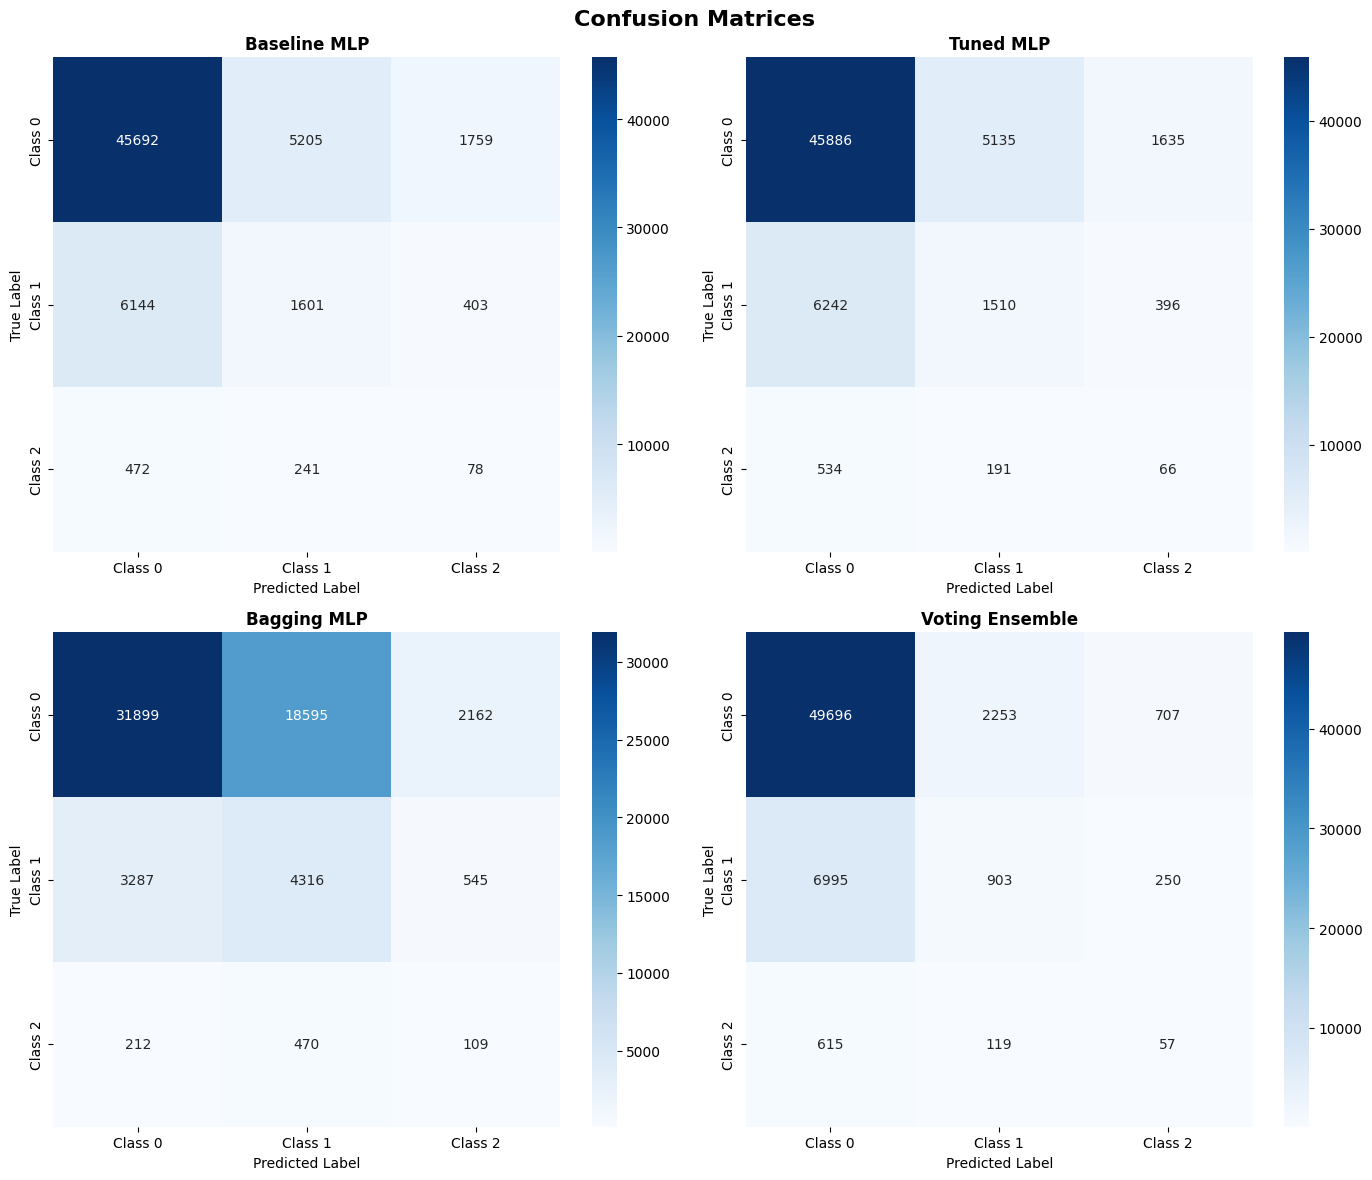


All Models Performance Metrics:


```
Baseline MLP:
  Accuracy : 0.7691
  Precision: 0.3785
  Recall   : 0.3876
  F1-Score : 0.3776
  AUC      : 0.6282

Tuned MLP:
  Accuracy : 0.7705
  Precision: 0.3746
  Recall   : 0.3801
  F1-Score : 0.3729
  AUC      : 0.6174

Bagging MLP:
  Accuracy : 0.5897
  Precision: 0.3748
  Recall   : 0.4244
  F1-Score : 0.3529
  AUC      : 0.6421

Voting Ensemble:
  Accuracy : 0.8224
  Precision: 0.3997
  Recall   : 0.3756
  F1-Score : 0.3750
  AUC      : 0.6792

```

Best model (by F1-Score): Baseline MLP

Best Model Performance Metrics:
  Accuracy : 0.7691
  Precision: 0.3785
  Recall   : 0.3876
  F1-Score : 0.3776 (PRIMARY METRIC)
  AUC      : 0.6282


In [ ]:
# 1. Metrics Comparison Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_list = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors_list[:len(results_df)])
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}',
                   ha='center', va='bottom', fontsize=9)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()
plt.close()

# 2. Metrics Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
metrics_for_heatmap = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']]
sns.heatmap(metrics_for_heatmap, annot=True, fmt='.4f', cmap='YlOrRd',
            cbar_kws={'label': 'Score'}, ax=ax)
ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

# 3. Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
for idx, (model_name, model_data) in enumerate(models.items()):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, model_data['y_test_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Class 0', 'Class 1', 'Class 2'],
                yticklabels=['Class 0', 'Class 1', 'Class 2'])
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()
plt.close()

# Display all metrics for all models
print("\nAll Models Performance Metrics:")
print("="*80)

output_lines = []
for _, row in results_df.iterrows():
    output_lines.append(f"{row['Model']}:")
    output_lines.append(f"  Accuracy : {row['Accuracy']:.4f}")
    output_lines.append(f"  Precision: {row['Precision']:.4f}")
    output_lines.append(f"  Recall   : {row['Recall']:.4f}")
    output_lines.append(f"  F1-Score : {row['F1-Score']:.4f}")
    output_lines.append(f"  AUC      : {row['AUC']:.4f}")
    output_lines.append("")
full_text = "\n".join(output_lines)
display(Markdown(f"```\n{full_text}\n```"))

# Determine best model based on F1-Score (since we're optimizing for class imbalance)
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model_metrics = results_df.loc[best_model_idx]

print(f"Best model (by F1-Score): {best_model_name}")
print(f"\nBest Model Performance Metrics:")
print(f"  Accuracy : {best_model_metrics['Accuracy']:.4f}")
print(f"  Precision: {best_model_metrics['Precision']:.4f}")
print(f"  Recall   : {best_model_metrics['Recall']:.4f}")
print(f"  F1-Score : {best_model_metrics['F1-Score']:.4f} (PRIMARY METRIC)")
print(f"  AUC      : {best_model_metrics['AUC']:.4f}")